In [29]:
import gensim.downloader as api
from scipy.spatial.distance import cosine
from gensim.models import Word2Vec
import pandas as pd
from urllib import request
import random as rn
import matplotlib.cm as cm
from sklearn.manifold import TSNE
import numpy as np

## Punto 2

### Parte 1 y 2

In [20]:
model = api.load("glove-wiki-gigaword-50")

In [ ]:
similar_words = ["glow", "radiance", "luminous", "sparkle", "gleam"]

different_words = ["walk", "thread", "common", "romantic", "infamous"]

In [22]:
emmbeddings_similares = {}
for word in similar_words:
    print(f"word: {word}\n")
    print(f"vector :\n")
    print(model[word])
    emmbeddings_similares[word] = model[word]
    print("\n")
emmbeddings_diferentes = {}
for word in different_words:
    print(f"word: {word}\n")
    print(f"vector :\n")
    print(model[word])
    emmbeddings_diferentes[word] = model[word]
    print("\n")

word: glow

vector :

[ 0.41723    1.0687    -0.036834   0.11403    0.40325   -0.21273
  0.14312   -0.48062   -0.11667    1.1456     0.28323    0.033365
  1.0105     0.84917   -0.31586    0.75469   -0.84957    0.21913
 -0.69091   -1.3931    -0.42795    0.44032    0.77783   -1.186
  0.31892    0.076777  -0.91977    1.8827     0.80547   -0.22597
  0.65275    0.91148   -0.43924   -1.0649    -0.18763    0.092741
 -0.038999  -0.43214   -0.002184  -0.83603   -0.29875    0.0049528
 -1.0131    -0.26949    0.25868    0.63695    0.24729   -1.0816
  0.12256   -0.79161  ]


word: radiance

vector :

[ 0.24982   0.74779  -0.13664   0.39467   0.17203   0.093232  1.0632
 -0.33884   1.1338    0.84274   0.71611   0.27197   0.64928  -0.030581
 -0.87112   0.27348  -0.113     0.27837  -0.1853   -0.30283  -0.32982
  0.44281   0.18487  -0.41231   0.40637   0.56464  -0.73357   0.61142
  0.78602   0.24642   0.025862  0.47904  -0.064114 -0.36171  -0.026988
  0.17856  -0.21328  -0.37104  -0.19594  -0.37589   0.

Una vez tenemos los vectores guardados y sus respectivas palabras compararemos las diferentes distancias coseno, esto nos permite que tan cerca en direccion estan las palabras y por ende en semantica.

Como se puede ver se tiene un promedio bastante que podriamos considerar bajo, en promedio estas palabras no estan cerca entre si, para tener la referencia el promedio de las palabras pasadas es casi .

### Comparacion con palabras con significado igual  

In [ ]:
max_cos = float("-inf")
suma = 0
for word1, embbeding1 in emmbeddings_similares.items():
    for word2, embbeding2 in emmbeddings_similares.items():
        cos_dist = cosine(embbeding1, embbeding2)
        print(f"similitud de {word1} y {word2}: {cos_dist}")
        max_cos = max(max_cos, cos_dist)
        suma += cos_dist
print(f"la maxima distancia es {max_cos}")
print(
    f"El promedio de distancia de las palabras es: {suma/(len(emmbeddings_similares)*len(emmbeddings_similares))}"
)

similitud de glow y glow: 1.2170779273290577e-08
similitud de glow y radiance: 0.42737630452523967
similitud de glow y luminous: 0.20419709898217375
similitud de glow y sparkle: 0.3531755436946856
similitud de glow y gleam: 0.3183993876133542
similitud de radiance y glow: 0.42737630452523967
similitud de radiance y radiance: 1.2007806970970591e-09
similitud de radiance y luminous: 0.31213696834505067
similitud de radiance y sparkle: 0.443641142931793
similitud de radiance y gleam: 0.4899626603856495
similitud de luminous y glow: 0.20419709898217375
similitud de luminous y radiance: 0.31213696834505067
similitud de luminous y luminous: 7.769797361056874e-09
similitud de luminous y sparkle: 0.4204837973668696
similitud de luminous y gleam: 0.36025093162401256
similitud de sparkle y glow: 0.3531755436946856
similitud de sparkle y radiance: 0.443641142931793
similitud de sparkle y luminous: 0.4204837973668696
similitud de sparkle y sparkle: 4.785987828270777e-09
similitud de sparkle y glea

### Comparacion con palabras con significado diferente  

In [ ]:
max_cos = float('-inf')
suma = 0
for word1, embbeding1 in emmbeddings_similares.items(): 
    for word2, embbeding2 in emmbeddings_diferentes.items(): 
        cos_dist = cosine(embbeding1,embbeding2)
        print(f"similitud de {word1} y {word2}: {cos_dist}")
        max_cos = max(max_cos,cos_import numpy as np de las palabras es: {suma/(len(emmbeddings_similares)*len(emmbeddings_similares))}")

similitud de glow y walk: 0.7874188651523246
similitud de glow y thread: 0.722852515384202
similitud de glow y common: 0.77680039026313
similitud de glow y romantic: 0.7303265679166464
similitud de glow y infamous: 0.9120098473974021
similitud de radiance y walk: 1.073780233674406
similitud de radiance y thread: 0.7086432301341119
similitud de radiance y common: 0.8340679918094657
similitud de radiance y romantic: 0.8286188932424494
similitud de radiance y infamous: 1.1543166991089793
similitud de luminous y walk: 0.950650865031323
similitud de luminous y thread: 0.7275954686676918
similitud de luminous y common: 0.7964625456711258
similitud de luminous y romantic: 0.6293525590254345
similitud de luminous y infamous: 0.9356369881806831
similitud de sparkle y walk: 0.9504604952535024
similitud de sparkle y thread: 0.7484761313473225
similitud de sparkle y common: 1.0331245951426666
similitud de sparkle y romantic: 0.6984815619548193
similitud de sparkle y infamous: 1.060413848775527
sim

teniendo en cuenta que la distancia entre las palabras similares es de 0.2978793 y el de las palabras de un significado contras las de significado mixto es de 0.8689009. Tenemos que el la comparacion de palabras similares es 2,916956297 mas pequenio que el de las palabras diferentes, por ende en general el w2v hace su trabajo generando vectores con diferentes dimensiones, donde la direccion de los vectores de las palabras similares van a tender a estas mas cerca que las de significados difentes, y asi es como se retornan los iguales y diferentes, comparando con la distancia coseno cual en direccion esta mas cerca.

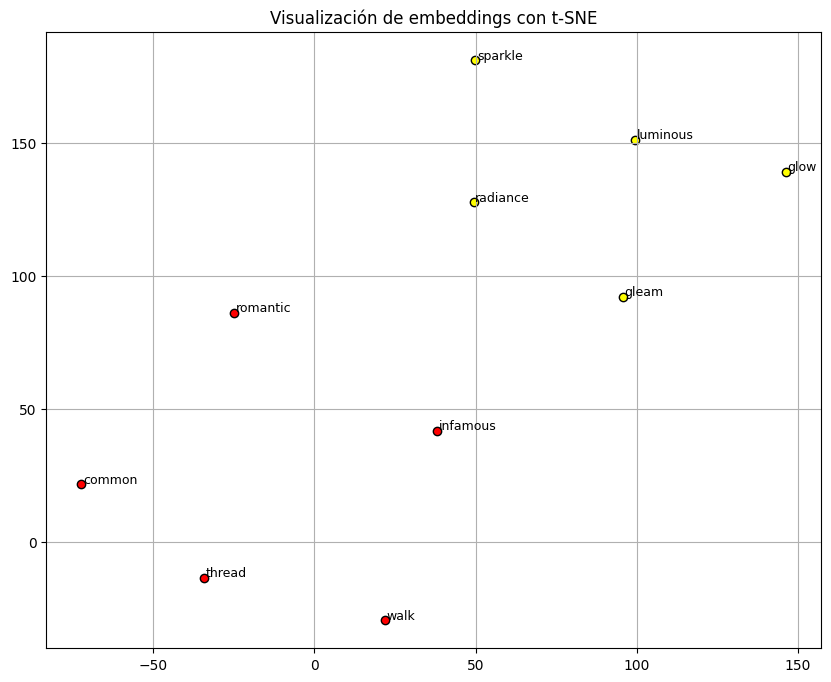

In [ ]:
words = list(emmbeddings_similares.keys()) + list(emmbeddings_diferentes.keys())
vectors = np.array(
    [emmbeddings_similares[word] for word in emmbeddings_similares]
    + [emmbeddings_diferentes[word] for word in emmbeddings_diferentes]
)

tsne = TSNE(n_components=2, random_state=42, perplexity=5)
vectors_tsne = tsne.fit_transform(vectors)

colors = ["yellow"] * len(emmbeddings_similares) + ["red"] * len(emmbeddings_diferentes)


plt.figure(figsize=(10, 8))
for i, word in enumerate(words):
    plt.scatter(vectors_tsne[i, 0], vectors_tsne[i, 1], c=colors[i], edgecolors="black")
    plt.text(vectors_tsne[i, 0] + 0.5, vectors_tsne[i, 1] + 0.5, word, fontsize=9)

plt.title("Visualización de embeddings con t-SNE")
plt.grid(True)
plt.show()

Lo que vemos arriba es la separacion semantica que logran los vectores generados, esta visualizacion la estamos haciendo utilizando una tecnica llamada t-SNE, la cual intenta preservar en una menor dimension las diferencias en cuanto a la similitud de los vectores, ayudandonos a poder hacer la visualizacion de los elementos, y como podemos ver aca, se puede ver claramente las diferencias entre las palabras, lo que parece curioso es que las palabras que no estan relacionadas se encuentren tan cerca una de otra.

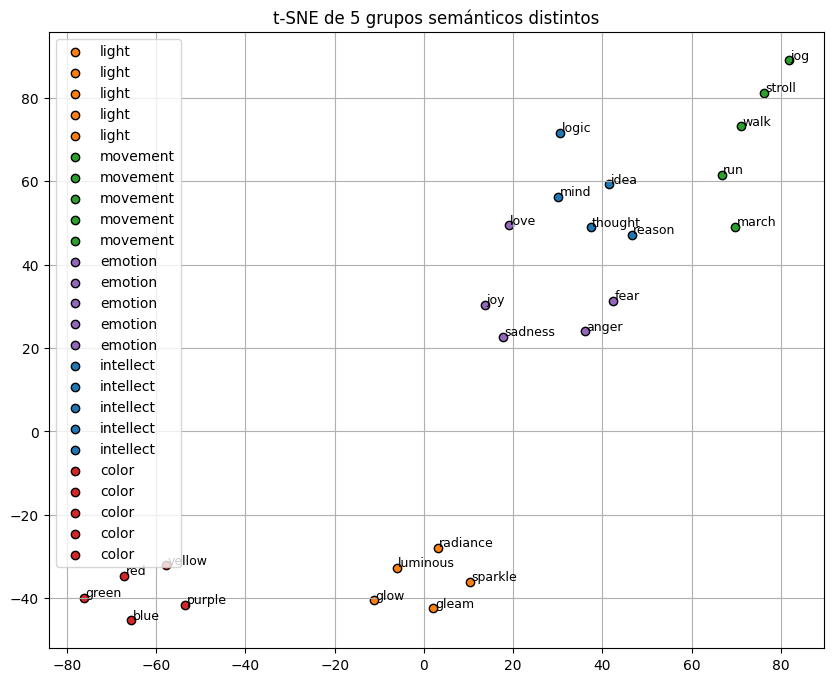

In [ ]:
groups = {
    "light": ["glow", "radiance", "luminous", "sparkle", "gleam"],
    "movement": ["walk", "run", "stroll", "march", "jog"],
    "emotion": ["joy", "sadness", "anger", "fear", "love"],
    "intellect": ["thought", "idea", "logic", "mind", "reason"],
    "color": ["red", "blue", "green", "yellow", "purple"],
}

group_vectors = []
group_labels = []
group_names = []

for group_name, words in groups.items():
    for word in words:
        group_vectors.append(model[word])
        group_labels.append(word)
        group_names.append(group_name)


vectors = np.array(group_vectors)
tsne = TSNE(n_components=2, random_state=42, perplexity=5)
vectors_tsne = tsne.fit_transform(vectors)


unique_groups = list(set(group_names))
color_map = {group: cm.tab10(i) for i, group in enumerate(unique_groups)}

plt.figure(figsize=(10, 8))
for i, word in enumerate(group_labels):
    group = group_names[i]
    color = color_map[group]
    plt.scatter(
        vectors_tsne[i, 0],
        vectors_tsne[i, 1],
        c=[color],
        label=group if group not in group_labels[:i] else "",
        edgecolors="black",
    )
    plt.text(vectors_tsne[i, 0] + 0.3, vectors_tsne[i, 1] + 0.3, word, fontsize=9)

plt.title("t-SNE de 5 grupos semánticos distintos")
plt.legend()
plt.grid(True)
plt.show()

En esta sección se observa que, efectivamente, los grupos de palabras aparecen agrupados entre sí en el espacio reducido. Algunos grupos resultan más cercanos que otros; por ejemplo, los relacionados con emoción e intelecto se encuentran próximos, lo cual es coherente si se considera que ambos pueden asociarse a un tema común como la psique o los procesos mentales. Este resultado evidencia cómo las palabras, a través de sus representaciones vectoriales, capturan relaciones semánticas que se reflejan en el espacio generado por t-SNE.

### Parte 3

In [ ]:
data = request.urlopen(
    "https://storage.googleapis.com/maps-premium/dataset/yes_complete/train.txt"
)
lines = data.read().decode("utf-8").split("\n")[2:]
playlists = [s.rstrip().split() for s in lines if len(s.split()) > 1]

In [ ]:
model = Word2Vec(
    playlists, vector_size=32, window=20, negative=50, min_count=1, workers=4
)

In [ ]:
songs_file = request.urlopen(
    "https://storage.googleapis.com/maps-premium/dataset/yes_complete/song_hash.txt"
)
songs_file = songs_file.read().decode("utf-8").split("\n")
songs = [s.rstrip().split("\t") for s in songs_file]
songs_df = pd.DataFrame(data=songs, columns=["id", "title", "artist"])
songs_df = songs_df.set_index("id")

In [7]:
lista_canciones = [song.strip() for song in list(songs_df.index)]
muestra = rn.sample(lista_canciones, k=10)

In [ ]:
for elemento in muestra:
    song_series = songs_df.iloc[int(elemento)]
    print(song_series.title)
    most_similar_songs = model.wv.most_similar(positive=elemento)
    for similar_song in most_similar_songs:
        cancion_similar = songs_df.iloc[int(similar_song[0])]
        print(
            f"      titulo :{cancion_similar.title} - artista:{cancion_similar.artist}"
        )
        print(f"              Que tan parecida es:{similar_song[1]}")

7x70
      titulo :Hallelujah - artista:Heather Williams
              Que tan parecida es:0.9997236132621765
      titulo :Children of God - artista:Third Day
              Que tan parecida es:0.9997186064720154
      titulo :I Refuse - artista:Josh Wilson
              Que tan parecida es:0.9996737837791443
      titulo :Take You Back - artista:Jeremy Camp
              Que tan parecida es:0.9996599555015564
      titulo :I Refuse - artista:Josh Wilson
              Que tan parecida es:0.9996581673622131
      titulo :Here With Me - artista:MercyMe
              Que tan parecida es:0.9996242523193359
      titulo :I Need You - artista:Jars Of Clay
              Que tan parecida es:0.999618649482727
      titulo :Your Great Name - artista:Natalie Grant
              Que tan parecida es:0.9996145367622375
      titulo :While I'm Waiting - artista:John Waller
              Que tan parecida es:0.9996106028556824
      titulo :Love Has Come - artista:Mark Schultz
              Que tan par

¿Y qué significa esto?

Word2Vec (w2v) es un modelo que cuenta con dos variantes principales, al menos en la implementación que ofrece la librería: CBOW y Skip-Gram. En este caso, nos enfocamos en la versión CBOW, la cual aprende a generar vectores basándose en el contexto de cada elemento, es decir, en las "palabras" que lo rodean. El objetivo del modelo es que las palabras (o canciones, en nuestro caso) que suelen aparecer cerca entre sí tengan vectores similares.

Por lo tanto, lo que estamos haciendo es medir la similitud entre canciones a partir de esta noción de proximidad en el contexto. Así, las canciones que el modelo considera similares son aquellas que suelen encontrarse juntas dentro de las playlists.

### Parte 4

En esta sección utilizamos el parámetro vector_size, el cual define la cantidad de dimensiones que tendrá cada vector de palabra. Este valor determina la capacidad del modelo para representar relaciones semánticas en un espacio vectorial. Intuitivamente, un número muy alto de dimensiones podría provocar que los vectores se dispersen demasiado, dificultando la identificación de similitudes. Por el contrario, un número demasiado bajo podría no ser suficiente para capturar adecuadamente la complejidad del significado semantico de la palabra.

In [ ]:
vector_sizes_probar = [4, 2, 10, 22, 32, 34]

In [ ]:
for size in vector_sizes_probar:
    model = Word2Vec(
        playlists, vector_size=size, window=20, negative=50, min_count=1, workers=4
    )
    print("el tamanio del vector es:")
    print(len(model.wv.get_vector("1")))

el tamanio del vector es:
4
el tamanio del vector es:
2
el tamanio del vector es:
10
el tamanio del vector es:
22
el tamanio del vector es:
32
el tamanio del vector es:
34
